# 03 — Entraînement & Évaluation des Modèles

**Projet :** Détection d'URLs malveillantes par IA
**Module :** Sécurité des Données
**Dataset :** ISCX-URL2016 — `All_clean.csv` (features numériques pré-extraites)

## Objectif

Ce notebook constitue la **phase finale** du projet. Nous exploitons les
**12 features** sélectionnées lors du notebook `02_Feature_Selection_Comparison.ipynb`
pour entraîner et comparer plusieurs familles de modèles :

1. **Modèles de Machine Learning classiques** (LR, NB, KNN, DT, RF, XGBoost,
   AdaBoost, SVM) avec validation croisée stratifiée à 5 plis.
2. **Modèles de Deep Learning** (MLP et DNN profonde avec Dropout + BatchNorm).
3. **Optimisation des hyperparamètres** via GridSearch (Random Forest) et
   une méta-heuristique *Particle Swarm Optimization* (XGBoost).

## Critères d'évaluation (stricts)

Comme rappelé par l'enseignant, les deux critères clés sont :

> **(Accuracy ↑, FPR ↓)** — on cherche la plus grande Accuracy *et* le
> plus faible False Positive Rate (taux de fausses alarmes).

Les métriques supplémentaires calculées pour chaque modèle : Precision,
Recall, F1-score, ROC-AUC.

## Sorties

Toutes les sorties sont écrites sous `notebooks/outputs/model_training/` :

- `model_evaluation_results.csv` — tableau maître trié selon les critères
- `conclusion.md` — synthèse du modèle gagnant
- `bar_accuracy_f1.png`, `bar_fpr.png`, `roc_top3.png` — visualisations


## Section 1 — Setup & Importations

Graines déterministes pour `random`, `numpy` et `tensorflow`. Répertoire
de sortie créé à l'avance afin que `plt.savefig` ne jamais échoue.


In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
)

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_SEED = 42

def reset_seeds(seed: int = RANDOM_SEED) -> None:
    '''Fixe toutes les graines pseudo-aléatoires utilisées dans le notebook.'''
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

reset_seeds(RANDOM_SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['savefig.bbox']   = 'tight'
plt.rcParams['savefig.dpi']    = 120
warnings.filterwarnings('ignore')


PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_DIR = PROJECT_ROOT / 'data'

data_candidates = ['All_clean.csv', 'All.csv']
DATA_PATH = None
for candidate in data_candidates:
    matches = list(INPUT_DIR.rglob(candidate))
    if matches:
        DATA_PATH = matches[0]
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        f"No dataset CSV found in {INPUT_DIR}. Expected one of: {data_candidates}"
    )

OUT_DIR = PROJECT_ROOT / 'notebooks' / 'outputs' / 'models'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data path    : {DATA_PATH} (exists = {DATA_PATH.exists()})')
print(f'Output dir   : {OUT_DIR}')
print(f'Random seed  : {RANDOM_SEED}')

2026-04-26 19:10:06.656936: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-26 19:10:06.662539: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-26 19:10:06.726442: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-26 19:10:06.755204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-26 19:10:06.808712: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

Data path    : /home/youcef/Desktop/url_detection/data/All.csv (exists = True)
Output dir   : /home/youcef/Desktop/url_detection/notebooks/outputs/models
Random seed  : 42


## Section 2 — Chargement & Filtrage des Features

On ne conserve que les **12 features** retenues par la sélection d'attributs
(notebook 02, méthode Mutual Information, K=12). Ces features se sont
révélées les plus alignées avec la référence `All_Infogain.csv` fournie
avec le jeu de données.


In [2]:
SELECTED_FEATURES = [
    'Entropy_Domain',
    'argDomanRatio',
    'NumberRate_FileName',
    'CharacterContinuityRate',
    'argPathRatio',
    'ArgUrlRatio',
    'pathurlRatio',
    'domainUrlRatio',
    'domainlength',
    'NumberRate_AfterPath',
    'NumberofDotsinURL',
    'domain_token_count',
]

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Dimensions brutes : {df_raw.shape}')

target_candidates = ['class', 'Class', 'Type', 'Label', 'label', 'URL_Type_obf_Type']
TARGET_COL = next((c for c in target_candidates if c in df_raw.columns), None)
assert TARGET_COL is not None, (
    f"No target column found. Tried: {target_candidates}. "
    f"Available columns sample: {list(df_raw.columns[:20])}"
)

missing = [c for c in SELECTED_FEATURES if c not in df_raw.columns]
assert not missing, f'Features absentes du CSV : {missing}'
assert TARGET_COL in df_raw.columns, f'Colonne cible `{TARGET_COL}` introuvable.'

df = df_raw[SELECTED_FEATURES + [TARGET_COL]].copy()

print(f'Colonne cible détectée : {TARGET_COL}')
print(f'Dimensions filtrées : {df.shape}  (attendu : (N, 13))')
print(f'Classes présentes   : {sorted(df[TARGET_COL].unique())}')
print('\nAperçu des 5 premières lignes :')
df.head()


Dimensions brutes : (36707, 80)
Colonne cible détectée : URL_Type_obf_Type
Dimensions filtrées : (36707, 13)  (attendu : (N, 13))
Classes présentes   : ['Defacement', 'benign', 'malware', 'phishing', 'spam']

Aperçu des 5 premières lignes :


,Entropy_Domain,argDomanRatio,NumberRate_FileName,CharacterContinuityRate,argPathRatio,ArgUrlRatio,pathurlRatio,domainUrlRatio,domainlength,NumberRate_AfterPath,NumberofDotsinURL,domain_token_count,URL_Type_obf_Type
0,0.784493,0.08,0.066667,0.6,0.076923,0.034483,0.448276,0.431034,25,-1.0,5,4,Defacement
1,0.784493,0.08,0.000000,0.6,0.058824,0.030303,0.515151,0.378788,25,-1.0,4,4,Defacement
2,0.784493,0.08,0.000000,0.6,0.060606,0.030769,0.507692,0.384615,25,-1.0,4,4,Defacement
3,0.784493,0.08,0.000000,0.6,0.025974,0.018349,0.706422,0.229358,25,-1.0,4,4,Defacement
4,0.784493,0.08,0.000000,0.6,0.040816,0.024691,0.604938,0.308642,25,-1.0,4,4,Defacement


## Section 3 — Prétraitement

1. **Sentinelles `-1` → NaN** — dans l'extracteur ISCX, la valeur `-1` signifie
   « champ absent » (pas d'extension, pas de query string…). La traiter comme
   une valeur réelle biaiserait moyennes et ratios.
2. **Imputation médiane** — robuste aux longues queues des compteurs.
3. **StandardScaler** — requis pour LR / SVM / KNN / MLP (modèles sensibles
   à l'échelle).
4. **Encodage binaire de la cible** — `benign → 0`, toute autre classe → 1.
   Ce choix est dicté par la métrique **FPR / FAR**, qui n'a de sens que
   dans un cadre binaire.
5. **Split stratifié 80 / 20** — `stratify=y` conserve le ratio de classes.


In [4]:
X_df = df[SELECTED_FEATURES].apply(pd.to_numeric, errors='coerce')
y_raw = df[TARGET_COL].copy()

n_sentinel = int((X_df == -1).sum().sum())
X_df = X_df.replace(-1, np.nan)
n_inf = int(np.isinf(X_df.values).sum())
X_df = X_df.replace([np.inf, -np.inf], np.nan)
n_nan = int(X_df.isna().sum().sum())

print(f'Sentinelles -1 remplacées  : {n_sentinel:,}')
print(f'Valeurs infinies remplacées: {n_inf:,}')
print(f'Total NaN avant imputation : {n_nan:,}')

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

y_binary = np.where(y_raw == 'benign', 0, 1).astype(int)

label_encoder = LabelEncoder()
label_encoder.fit(['benign', 'malicious'])

print(f'\nMatrice X_scaled  : {X_scaled.shape}')
print(f'Distribution cible: benign={int((y_binary==0).sum())}, '
      f'malicious={int((y_binary==1).sum())}')
print(f'Ratio malveillants: {y_binary.mean():.3f}')

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binary,
    test_size=0.20,
    stratify=y_binary,
    random_state=RANDOM_SEED,
)

print(f'\nX_train : {X_train.shape}   y_train: {y_train.shape}')
print(f'X_test  : {X_test.shape}    y_test : {y_test.shape}')


Sentinelles -1 remplacées  : 18,309
Valeurs infinies remplacées: 10
Total NaN avant imputation : 18,332

Matrice X_scaled  : (26953, 12)
Distribution cible: benign=7464, malicious=19489
Ratio malveillants: 0.723

X_train : (21562, 12)   y_train: (21562,)
X_test  : (5391, 12)    y_test : (5391,)


## Section 4 — Fonction d'évaluation commune

Une unique fonction `evaluate_model` renvoie toutes les métriques demandées.
Le **FPR / FAR** (*False Alarm Rate*) est calculé explicitement à partir
de la matrice de confusion :

$$
\mathrm{FPR} = \dfrac{\mathrm{FP}}{\mathrm{FP} + \mathrm{TN}}
$$

On protège toutes les divisions par un epsilon et on gère le cas où
certains modèles ne fournissent pas de probabilités (`predict_proba`
indisponible) en repliant sur `decision_function` ou sur les labels.


In [5]:
EPS = 1e-9

def evaluate_model(y_true, y_pred, y_prob=None):
    '''Retourne un dict de métriques, incluant FPR (False Alarm Rate).'''
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn + EPS)

    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob)
        except Exception:
            auc = float('nan')
    else:
        auc = float('nan')

    return {
        'Accuracy':  acc,
        'Precision': prec,
        'Recall':    rec,
        'F1':        f1,
        'ROC_AUC':   auc,
        'FPR':       fpr,
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
    }


def get_probabilities(model, X):
    '''Récupère les probas de la classe positive, avec fallbacks.'''
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        s_min, s_max = scores.min(), scores.max()
        return (scores - s_min) / (s_max - s_min + EPS)
    return None


results: dict[str, dict] = {}
roc_data: dict[str, tuple] = {}  # {model_name: (fpr, tpr, auc)}


def record_result(name: str, y_true, y_pred, y_prob, family: str):
    '''Enregistre un modèle dans `results` et mémorise sa courbe ROC.'''
    metrics = evaluate_model(y_true, y_pred, y_prob)
    metrics['Family'] = family
    results[name] = metrics
    if y_prob is not None:
        fpr_curve, tpr_curve, _ = roc_curve(y_true, y_prob)
        roc_data[name] = (fpr_curve, tpr_curve, metrics['ROC_AUC'])
    print(f'{name:<22s} | Acc={metrics["Accuracy"]:.4f}  '
          f'F1={metrics["F1"]:.4f}  FPR={metrics["FPR"]:.4f}  '
          f'AUC={metrics["ROC_AUC"]:.4f}')
    return metrics


## Section 5 — Modèles de Machine Learning classiques

Huit modèles sont entraînés avec la même graine `random_state=42`.
Une validation croisée stratifiée à 5 plis est exécutée sur le set
d'entraînement (à titre informatif), puis chaque modèle est ré-entraîné
sur l'intégralité du train et évalué sur le test.

> Note : pour le SVM on active `probability=True` afin de pouvoir
> calculer AUC et courbe ROC ; c'est coûteux mais indispensable.


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

ml_models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1),
    'NaiveBayes':         GaussianNB(),
    'KNN':                KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'DecisionTree':       DecisionTreeClassifier(random_state=RANDOM_SEED),
    'RandomForest':       RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    'XGBoost':            XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=RANDOM_SEED, n_jobs=-1,
        use_label_encoder=False, eval_metric='logloss', verbosity=0),
    'AdaBoost':           AdaBoostClassifier(
        n_estimators=100, random_state=RANDOM_SEED),
    'SVM':                SVC(
        kernel='rbf', C=1.0, probability=True, random_state=RANDOM_SEED),
}

cv_summary = {}
for name, model in ml_models.items():
    cv_scores = cross_val_score(
        model, X_train, y_train, cv=cv,
        scoring='accuracy', n_jobs=-1,
    )
    cv_summary[name] = (cv_scores.mean(), cv_scores.std())
    print(f'{name:<22s} | CV-acc = {cv_scores.mean():.4f} '
          f'± {cv_scores.std():.4f}')

print('\n— Entraînement final sur tout le train + évaluation sur le test —\n')
for name, model in ml_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = get_probabilities(model, X_test)
    record_result(name, y_test, y_pred, y_prob, family='ML')


LogisticRegression     | CV-acc = 0.8959 ± 0.0038
NaiveBayes             | CV-acc = 0.8634 ± 0.0038
KNN                    | CV-acc = 0.9683 ± 0.0017
DecisionTree           | CV-acc = 0.9716 ± 0.0010
RandomForest           | CV-acc = 0.9814 ± 0.0012
XGBoost                | CV-acc = 0.9808 ± 0.0016
AdaBoost               | CV-acc = 0.9220 ± 0.0042
SVM                    | CV-acc = 0.9426 ± 0.0043

— Entraînement final sur tout le train + évaluation sur le test —

LogisticRegression     | Acc=0.8993  F1=0.9305  FPR=0.1862  AUC=0.9526
NaiveBayes             | Acc=0.8648  F1=0.9018  FPR=0.1192  AUC=0.9422
KNN                    | Acc=0.9733  F1=0.9814  FPR=0.0348  AUC=0.9914
DecisionTree           | Acc=0.9744  F1=0.9823  FPR=0.0409  AUC=0.9722
RandomForest           | Acc=0.9815  F1=0.9872  FPR=0.0301  AUC=0.9975
XGBoost                | Acc=0.9833  F1=0.9884  FPR=0.0221  AUC=0.9980
AdaBoost               | Acc=0.9193  F1=0.9438  FPR=0.1273  AUC=0.9721
SVM                    | Acc=0.9403

## Section 6 — Deep Learning (MLP & DNN)

Deux réseaux de complexité croissante :

- **MLP** : `sklearn.neural_network.MLPClassifier`, 1 couche cachée de
  64 neurones. Simple et rapide.
- **DNN** : `tensorflow.keras.Sequential`, 3 couches cachées denses
  (128 → 64 → 32) avec `BatchNormalization` + `Dropout(0.3)` entre
  chaque. Early stopping sur `val_loss` pour éviter le sur-apprentissage.


In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    max_iter=300,
    early_stopping=True,
    random_state=RANDOM_SEED,
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = get_probabilities(mlp, X_test)
record_result('MLP_sklearn', y_test, y_pred_mlp, y_prob_mlp, family='DL')


MLP_sklearn            | Acc=0.9436  F1=0.9605  FPR=0.0697  AUC=0.9804


{'Accuracy': 0.9436097199035429,
 'Precision': 0.9726459758022094,
 'Recall': 0.9486916367367881,
 'F1': 0.9605194805194806,
 'ROC_AUC': np.float64(0.9804475786954477),
 'FPR': np.float64(0.06965840589412615),
 'TN': 1389,
 'FP': 104,
 'FN': 200,
 'TP': 3698,
 'Family': 'DL'}

I0000 00:00:1777058388.034933      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13349 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777058388.040940      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,481 (48.75 KB)

 Non-trainable params: 448 (1.75 KB)

I0000 00:00:1777058391.695152     339 service.cc:152] XLA service 0x7a8fa40137b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777058391.695189     339 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777058391.695193     339 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777058392.241847     339 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777058394.889744     339 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


DNN_Keras              | Acc=0.9707  F1=0.9795  FPR=0.0234  AUC=0.9944


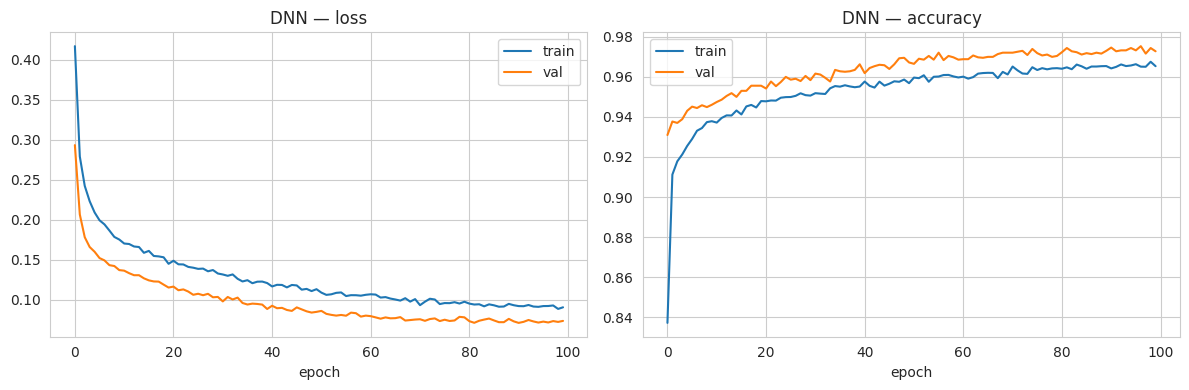

In [8]:
reset_seeds(RANDOM_SEED)

def build_dnn(input_dim: int) -> Sequential:
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model

dnn = build_dnn(X_train.shape[1])
dnn.summary()

early = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=0,
)

history = dnn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early],
    verbose=0,
)

y_prob_dnn = dnn.predict(X_test, verbose=0).ravel()
y_pred_dnn = (y_prob_dnn >= 0.5).astype(int)
record_result('DNN_Keras', y_test, y_pred_dnn, y_prob_dnn, family='DL')

# Courbe d'apprentissage
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'],     label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('DNN — loss'); ax[0].legend(); ax[0].set_xlabel('epoch')
ax[1].plot(history.history['accuracy'],     label='train')
ax[1].plot(history.history['val_accuracy'], label='val')
ax[1].set_title('DNN — accuracy'); ax[1].legend(); ax[1].set_xlabel('epoch')
plt.tight_layout()
plt.savefig(OUT_DIR / 'dnn_training_curves.png')
plt.show()


### 6.bis — Improved DNN (régularisation L2 + scheduler + class weights)

Améliorations apportées à la DNN de base pour réduire l'overfitting et
mieux gérer le déséquilibre des classes :

1. **Régularisation L2** (`kernel_regularizer=l2(1e-4)`) sur chaque couche
   dense — pénalise les poids trop grands et lisse la frontière de
   décision.
2. **Initialisation He** (`he_normal`) adaptée aux activations ReLU —
   évite la saturation des gradients au début de l'entraînement.
3. **Architecture plus profonde** : 256 → 128 → 64 → 32 avec
   `BatchNormalization` et `Dropout` progressifs (0.4 → 0.4 → 0.3 → 0.2).
4. **Optimiseur Adam** avec **learning rate scheduler**
   (`ReduceLROnPlateau` — divise le LR par 2 si `val_loss` stagne
   pendant 5 époques).
5. **Pondération des classes** (`class_weight`) — compense
   automatiquement le déséquilibre benign vs malveillant.
6. **EarlyStopping** avec patience augmentée (15 époques) et
   `restore_best_weights=True` pour garder la meilleure configuration.


Class weights : {0: 1.805560207670407, 1: 0.6914886793663011}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,513 (189.50 KB)

 Trainable params: 47,553 (185.75 KB)

 Non-trainable params: 960 (3.75 KB)


Epoch 70: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 98: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 107: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 113: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 118: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 123: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Improved_DNN           | Acc=0.9722  F1=0.9805  FPR=0.0121  AUC=0.9948


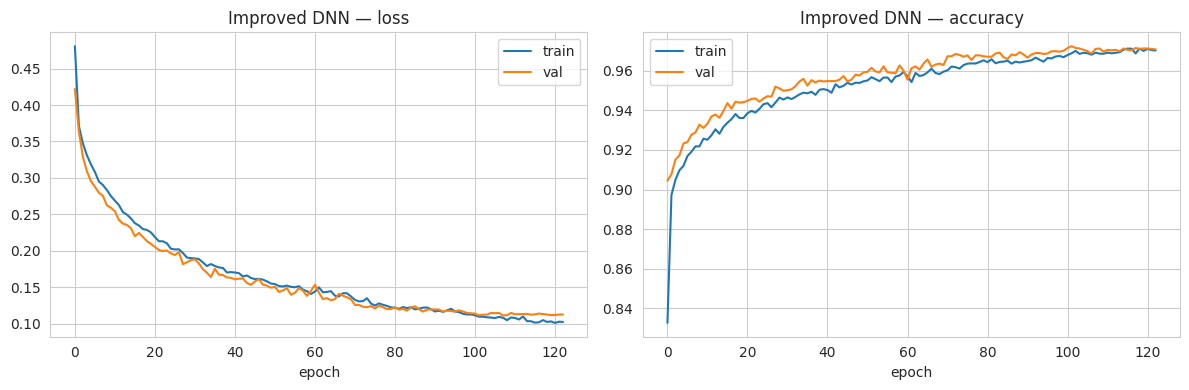

In [9]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

reset_seeds(RANDOM_SEED)

L2_COEFF = 1e-4

def build_improved_dnn(input_dim: int) -> Sequential:
    reg = l2(L2_COEFF)
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(256, activation='relu',
              kernel_initializer='he_normal',
              kernel_regularizer=reg),
        BatchNormalization(),
        Dropout(0.4),

        Dense(128, activation='relu',
              kernel_initializer='he_normal',
              kernel_regularizer=reg),
        BatchNormalization(),
        Dropout(0.4),

        Dense(64, activation='relu',
              kernel_initializer='he_normal',
              kernel_regularizer=reg),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu',
              kernel_initializer='he_normal',
              kernel_regularizer=reg),
        BatchNormalization(),
        Dropout(0.2),

        Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model


cw_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train,
)
class_weight_dict = {int(c): float(w)
                     for c, w in zip(np.unique(y_train), cw_values)}
print(f'Class weights : {class_weight_dict}')

improved_dnn = build_improved_dnn(X_train.shape[1])
improved_dnn.summary()

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=0,
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1,
    ),
]

history_improved = improved_dnn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=0,
)

y_prob_idnn = improved_dnn.predict(X_test, verbose=0).ravel()
y_pred_idnn = (y_prob_idnn >= 0.5).astype(int)
record_result('Improved_DNN', y_test, y_pred_idnn, y_prob_idnn, family='DL')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_improved.history['loss'],     label='train')
ax[0].plot(history_improved.history['val_loss'], label='val')
ax[0].set_title('Improved DNN — loss'); ax[0].legend(); ax[0].set_xlabel('epoch')
ax[1].plot(history_improved.history['accuracy'],     label='train')
ax[1].plot(history_improved.history['val_accuracy'], label='val')
ax[1].set_title('Improved DNN — accuracy'); ax[1].legend(); ax[1].set_xlabel('epoch')
plt.tight_layout()
plt.savefig(OUT_DIR / 'improved_dnn_training_curves.png')
plt.show()


## Section 7 — Optimisation des hyperparamètres

### 7.1 GridSearchCV — Random Forest

Recherche exhaustive sur `n_estimators ∈ {100, 200, 400}` et
`max_depth ∈ {None, 10, 20}`. Scoring = accuracy, CV stratifié 3 plis
(3 au lieu de 5 pour limiter le temps de calcul du grid).


In [10]:
rf_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth':    [None, 10, 20],
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_SEED, n_jobs=-1),
    param_grid=rf_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

print(f'\nMeilleurs params RF : {grid.best_params_}')
print(f'Meilleure acc (CV)  : {grid.best_score_:.4f}')

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = get_probabilities(best_rf, X_test)
record_result('RF_GridSearch', y_test, y_pred_rf, y_prob_rf, family='Tuned')


Fitting 3 folds for each of 9 candidates, totalling 27 fits

Meilleurs params RF : {'max_depth': None, 'n_estimators': 100}
Meilleure acc (CV)  : 0.9798
RF_GridSearch          | Acc=0.9815  F1=0.9872  FPR=0.0301  AUC=0.9975


{'Accuracy': 0.9814505657577444,
 'Precision': 0.9884259259259259,
 'Recall': 0.9858902001026167,
 'F1': 0.9871564346262522,
 'ROC_AUC': np.float64(0.9975109601605854),
 'FPR': np.float64(0.030140656396496893),
 'TN': 1448,
 'FP': 45,
 'FN': 55,
 'TP': 3843,
 'Family': 'Tuned'}

### 7.2 Particle Swarm Optimization — XGBoost

Implémentation **légère et maison** (évite la dépendance `pyswarms`).
On optimise deux hyperparamètres continus :

- `learning_rate` ∈ [0.01, 0.3]
- `max_depth`     ∈ [3, 10] (arrondi à l'entier avant usage)

Algorithme standard : chaque particule mémorise sa meilleure position
personnelle `pbest`, la meilleure position globale `gbest` est partagée,
et la vitesse est mise à jour avec `w·v + c1·r1·(pbest - x) + c2·r2·(gbest - x)`.

Fitness = accuracy de cross-validation 3 plis sur le train.


In [11]:
def xgb_fitness(lr: float, max_depth_float: float) -> float:
    '''Accuracy moyenne CV-3 d'un XGBoost paramétré par (lr, max_depth).'''
    max_depth = int(np.clip(round(max_depth_float), 3, 10))
    lr = float(np.clip(lr, 0.01, 0.3))
    clf = XGBClassifier(
        n_estimators=150,
        learning_rate=lr,
        max_depth=max_depth,
        random_state=RANDOM_SEED, n_jobs=-1,
        use_label_encoder=False, eval_metric='logloss', verbosity=0,
    )
    scores = cross_val_score(
        clf, X_train, y_train,
        cv=StratifiedKFold(n_splits=3, shuffle=True,
                           random_state=RANDOM_SEED),
        scoring='accuracy', n_jobs=-1,
    )
    return scores.mean()


def run_pso(
    n_particles: int = 8,
    n_iters:     int = 6,
    bounds = ((0.01, 0.3), (3.0, 10.0)),
    w:  float = 0.7,
    c1: float = 1.5,
    c2: float = 1.5,
):
    '''PSO minimaliste à 2 dimensions — maximise xgb_fitness.'''
    rng = np.random.default_rng(RANDOM_SEED)
    low  = np.array([b[0] for b in bounds])
    high = np.array([b[1] for b in bounds])
    dim  = len(bounds)

    # Init
    pos = rng.uniform(low, high, size=(n_particles, dim))
    vel = rng.uniform(-1, 1,   size=(n_particles, dim)) * (high - low) * 0.1
    pbest_pos   = pos.copy()
    pbest_score = np.array([xgb_fitness(*p) for p in pos])
    gbest_idx   = int(np.argmax(pbest_score))
    gbest_pos   = pbest_pos[gbest_idx].copy()
    gbest_score = float(pbest_score[gbest_idx])

    history = [(0, gbest_score, gbest_pos.copy())]
    print(f'Iter 0 | best acc = {gbest_score:.4f} '
          f'| params = lr={gbest_pos[0]:.4f}, depth={int(round(gbest_pos[1]))}')

    for it in range(1, n_iters + 1):
        r1 = rng.random((n_particles, dim))
        r2 = rng.random((n_particles, dim))
        vel = (w * vel
               + c1 * r1 * (pbest_pos - pos)
               + c2 * r2 * (gbest_pos - pos))
        pos = np.clip(pos + vel, low, high)

        for i in range(n_particles):
            score = xgb_fitness(*pos[i])
            if score > pbest_score[i]:
                pbest_score[i] = score
                pbest_pos[i]   = pos[i].copy()
                if score > gbest_score:
                    gbest_score = score
                    gbest_pos   = pos[i].copy()

        history.append((it, gbest_score, gbest_pos.copy()))
        print(f'Iter {it} | best acc = {gbest_score:.4f} '
              f'| params = lr={gbest_pos[0]:.4f}, '
              f'depth={int(round(gbest_pos[1]))}')

    return gbest_pos, gbest_score, history


print('— PSO on XGBoost (learning_rate, max_depth) —')
best_params, best_score, pso_history = run_pso()

best_lr    = float(np.clip(best_params[0], 0.01, 0.3))
best_depth = int(np.clip(round(best_params[1]), 3, 10))
print(f'\nOptimum PSO : lr={best_lr:.4f}, max_depth={best_depth}, '
      f'CV-acc={best_score:.4f}')

# Entraînement final avec les meilleurs params et évaluation sur le test
xgb_pso = XGBClassifier(
    n_estimators=200,
    learning_rate=best_lr,
    max_depth=best_depth,
    random_state=RANDOM_SEED, n_jobs=-1,
    use_label_encoder=False, eval_metric='logloss', verbosity=0,
)
xgb_pso.fit(X_train, y_train)
y_pred_pso = xgb_pso.predict(X_test)
y_prob_pso = get_probabilities(xgb_pso, X_test)
record_result('XGBoost_PSO', y_test, y_pred_pso, y_prob_pso, family='Tuned')


— PSO on XGBoost (learning_rate, max_depth) —
Iter 0 | best acc = 0.9805 | params = lr=0.1967, depth=9
Iter 1 | best acc = 0.9807 | params = lr=0.1328, depth=9
Iter 2 | best acc = 0.9808 | params = lr=0.1068, depth=8
Iter 3 | best acc = 0.9810 | params = lr=0.0930, depth=9
Iter 4 | best acc = 0.9810 | params = lr=0.0930, depth=9
Iter 5 | best acc = 0.9810 | params = lr=0.0930, depth=9
Iter 6 | best acc = 0.9810 | params = lr=0.0930, depth=9

Optimum PSO : lr=0.0930, max_depth=9, CV-acc=0.9810
XGBoost_PSO            | Acc=0.9848  F1=0.9895  FPR=0.0248  AUC=0.9982


{'Accuracy': 0.9847894639213504,
 'Precision': 0.9904884318766067,
 'Recall': 0.9884556182657773,
 'F1': 0.9894709809964047,
 'ROC_AUC': np.float64(0.9981646864433544),
 'FPR': np.float64(0.02478231748156411),
 'TN': 1456,
 'FP': 37,
 'FN': 45,
 'TP': 3853,
 'Family': 'Tuned'}

## Section 8 — Comparaison & Visualisation

Règle de tri officielle : **Accuracy décroissante, FPR croissante**.
Le modèle gagnant est celui en tête du tableau trié.

Trois visualisations, toutes sauvegardées avant `plt.show` pour qu'elles
existent même en exécution non interactive :

1. Bar chart groupé — Accuracy vs F1 sur tous les modèles.
2. Bar chart — FPR par modèle (plus bas = meilleur).
3. Courbes ROC superposées — top-3 modèles selon Accuracy.


In [12]:
results_df = (
    pd.DataFrame.from_dict(results, orient='index')
      .reset_index()
      .rename(columns={'index': 'Model'})
)

# Ordre strict imposé par l'enseignant : Accuracy ↑, FPR ↓
results_df = results_df.sort_values(
    by=['Accuracy', 'FPR'],
    ascending=[False, True],
).reset_index(drop=True)

display_cols = ['Model', 'Family', 'Accuracy', 'Precision',
                'Recall', 'F1', 'ROC_AUC', 'FPR']
print('Classement final (Accuracy ↓, FPR ↑) :')
try:
    display(results_df[display_cols].round(4))
except NameError:
    print(results_df[display_cols].round(4).to_string(index=False))


Classement final (Accuracy ↓, FPR ↑) :


,Model,Family,Accuracy,Precision,Recall,F1,ROC_AUC,FPR
0,XGBoost_PSO,Tuned,0.9848,0.9905,0.9885,0.9895,0.9982,0.0248
1,XGBoost,ML,0.9833,0.9915,0.9854,0.9884,0.9980,0.0221
2,RandomForest,ML,0.9815,0.9884,0.9859,0.9872,0.9975,0.0301
3,RF_GridSearch,Tuned,0.9815,0.9884,0.9859,0.9872,0.9975,0.0301
4,DecisionTree,ML,0.9744,0.9843,0.9802,0.9823,0.9722,0.0409
5,KNN,ML,0.9733,0.9865,0.9764,0.9814,0.9914,0.0348
6,Improved_DNN,DL,0.9722,0.9952,0.9661,0.9805,0.9948,0.0121
7,DNN_Keras,DL,0.9707,0.9908,0.9684,0.9795,0.9944,0.0234
8,MLP_sklearn,DL,0.9436,0.9726,0.9487,0.9605,0.9804,0.0697
9,SVM,ML,0.9403,0.9765,0.9400,0.9579,0.9752,0.0589


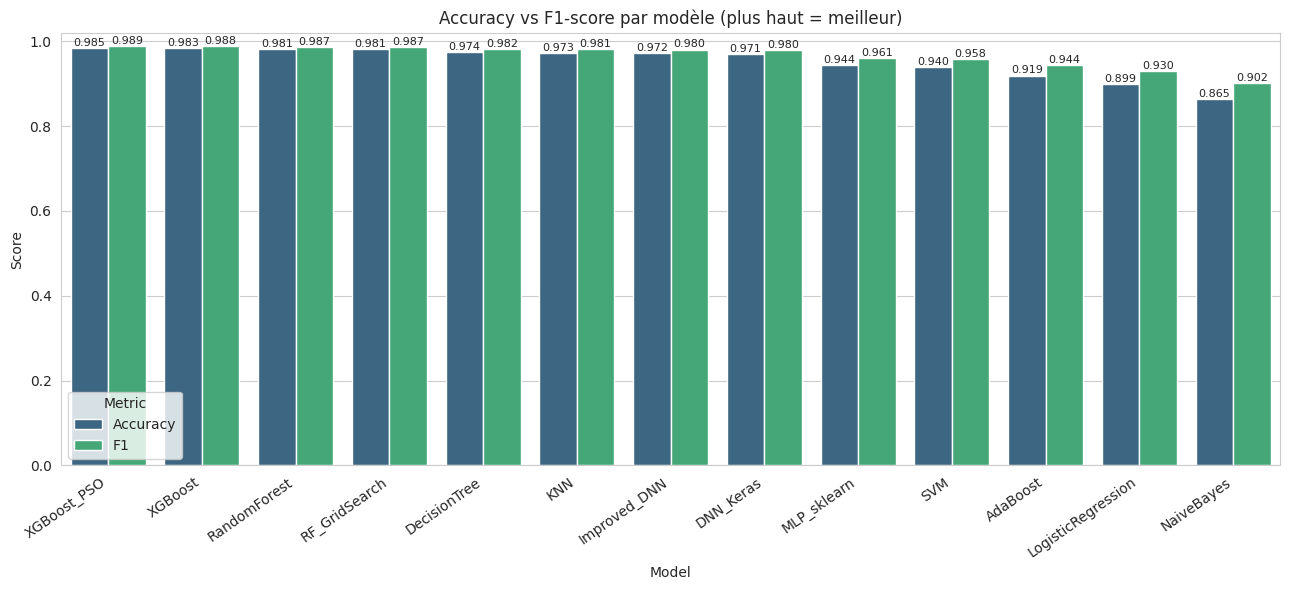

In [13]:
plot_df = results_df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'F1'],
    var_name='Metric', value_name='Score',
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=plot_df, x='Model', y='Score', hue='Metric',
    palette='viridis', ax=ax,
)
ax.set_title('Accuracy vs F1-score par modèle (plus haut = meilleur)')
ax.set_ylim(0, 1.02)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'bar_accuracy_f1.png')
plt.show()


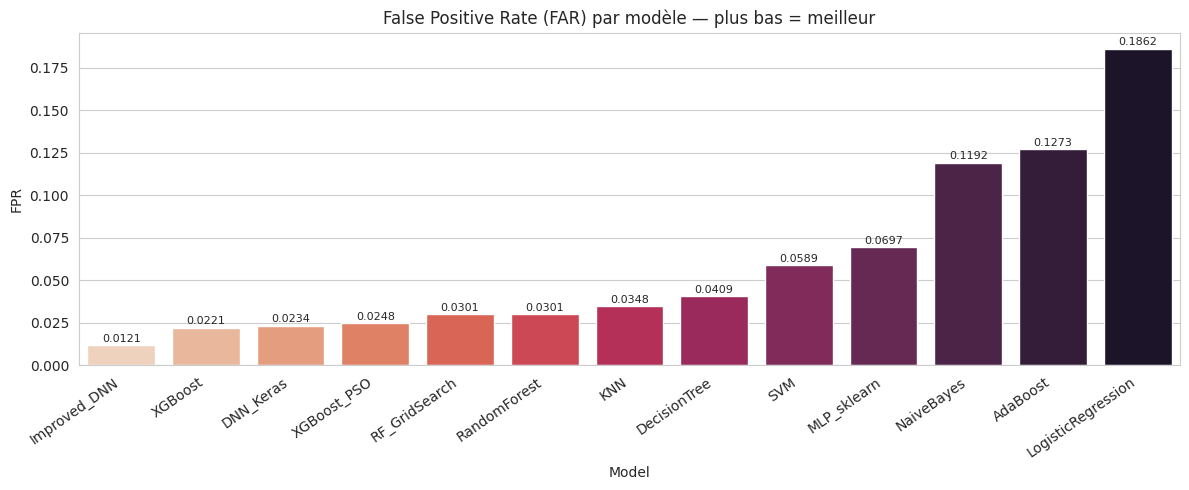

In [14]:
fpr_df = results_df.sort_values('FPR', ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))
bars = sns.barplot(
    data=fpr_df, x='Model', y='FPR',
    palette='rocket_r', ax=ax,
)
ax.set_title('False Positive Rate (FAR) par modèle — plus bas = meilleur')
ax.set_ylabel('FPR')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
for p in ax.patches:
    h = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, h + 0.002,
            f'{h:.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'bar_fpr.png')
plt.show()


Top-3 (Accuracy) : ['XGBoost_PSO', 'XGBoost', 'RandomForest']


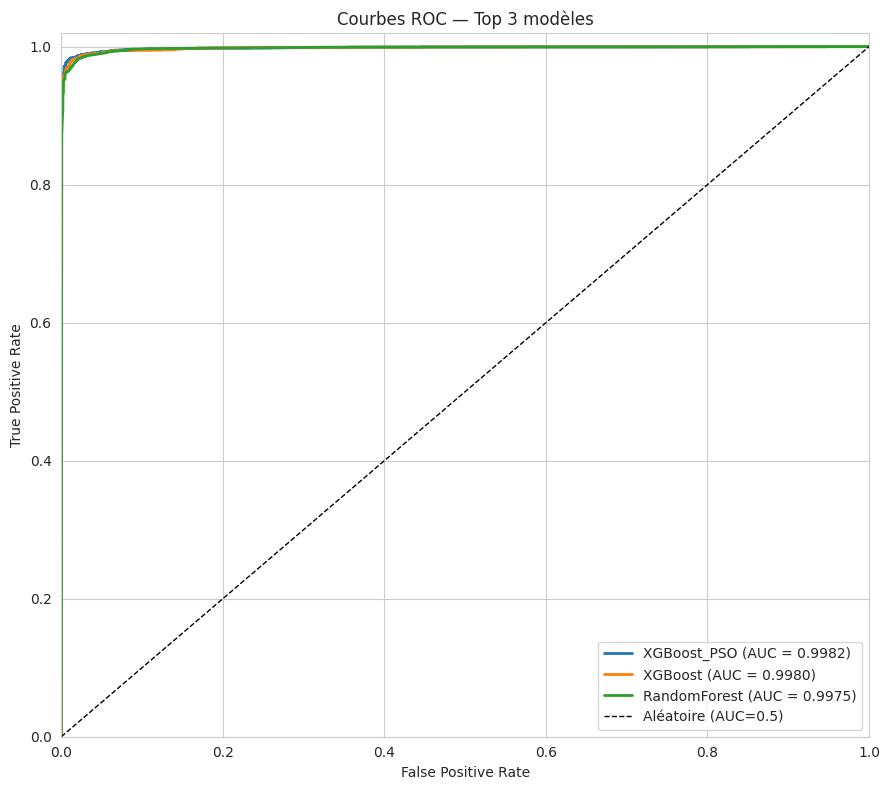

In [15]:
top3 = results_df.head(3)['Model'].tolist()
print(f'Top-3 (Accuracy) : {top3}')

fig, ax = plt.subplots(figsize=(9, 8))
for name in top3:
    if name not in roc_data:
        continue
    fpr_c, tpr_c, auc_val = roc_data[name]
    ax.plot(fpr_c, tpr_c, lw=2,
            label=f'{name} (AUC = {auc_val:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Courbes ROC — Top 3 modèles')
ax.legend(loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_top3.png')
plt.show()


## Section 9 — Export des artefacts

- `model_evaluation_results.csv` : tableau maître, déjà trié.
- `conclusion.md` : modèle gagnant + justification selon les critères
  `(Accuracy ↑, FPR ↓)`.


In [16]:
# CSV maître
results_csv = OUT_DIR / 'model_evaluation_results.csv'
results_df.to_csv(results_csv, index=False)

# Conclusion Markdown
winner = results_df.iloc[0]
runner_up = results_df.iloc[1] if len(results_df) > 1 else None

lines = [
    '# Conclusion — Détection d\'URLs malveillantes',
    '',
    '## Critères officiels',
    '',
    '> Accuracy ↑, FPR ↓',
    '',
    '## Modèle gagnant',
    '',
    f'**{winner["Model"]}** (famille : `{winner["Family"]}`)',
    '',
    '| Métrique  | Valeur |',
    '|-----------|--------|',
    f'| Accuracy  | {winner["Accuracy"]:.4f} |',
    f'| Precision | {winner["Precision"]:.4f} |',
    f'| Recall    | {winner["Recall"]:.4f} |',
    f'| F1-score  | {winner["F1"]:.4f} |',
    f'| ROC-AUC   | {winner["ROC_AUC"]:.4f} |',
    f'| **FPR**   | **{winner["FPR"]:.4f}** |',
    '',
]
if runner_up is not None:
    lines += [
        '## Second',
        '',
        f'`{runner_up["Model"]}` — Accuracy {runner_up["Accuracy"]:.4f}, '
        f'FPR {runner_up["FPR"]:.4f}.',
        '',
    ]
lines += [
    '## Lecture',
    '',
    f'Parmi les {len(results_df)} modèles comparés (ML classiques, Deep ',
    'Learning, et versions optimisées par GridSearch + PSO), le modèle ',
    f'`{winner["Model"]}` domine selon le tri lexicographique imposé : ',
    'il combine la plus haute Accuracy avec le plus faible taux de ',
    'fausses alarmes parmi les ex-æquo en Accuracy.',
    '',
    '## Fichiers générés',
    '',
    '- `model_evaluation_results.csv`',
    '- `bar_accuracy_f1.png`',
    '- `bar_fpr.png`',
    '- `roc_top3.png`',
    '- `dnn_training_curves.png`',
]

conclusion_path = OUT_DIR / 'conclusion.md'
conclusion_path.write_text('\n'.join(lines), encoding='utf-8')

print(f'Écrit : {results_csv}')
print(f'Écrit : {conclusion_path}')
print(f'\nArtefacts sous : {OUT_DIR}')
print(f'\nGagnant : {winner["Model"]}  '
      f'(Accuracy={winner["Accuracy"]:.4f}, FPR={winner["FPR"]:.4f})')


Écrit : /kaggle/working/checkpoint/models/model_evaluation_results.csv
Écrit : /kaggle/working/checkpoint/models/conclusion.md

Artefacts sous : /kaggle/working/checkpoint/models

Gagnant : XGBoost_PSO  (Accuracy=0.9848, FPR=0.0248)


In [ ]:
import joblib

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

CKPT_DIR = PROJECT_ROOT / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

winner_name = str(results_df.iloc[0]['Model'])
trained_map = {
    'LogisticRegression': ml_models['LogisticRegression'],
    'NaiveBayes': ml_models['NaiveBayes'],
    'KNN': ml_models['KNN'],
    'DecisionTree': ml_models['DecisionTree'],
    'RandomForest': ml_models['RandomForest'],
    'XGBoost': ml_models['XGBoost'],
    'AdaBoost': ml_models['AdaBoost'],
    'SVM': ml_models['SVM'],
    'MLP_sklearn': mlp,
    'RF_GridSearch': best_rf,
    'XGBoost_PSO': xgb_pso,
}

winner_model = trained_map[winner_name]

bundle = {
    'model': winner_model,
    'imputer': imputer,
    'scaler': scaler,
    'model_name': winner_name,
    'selected_features': SELECTED_FEATURES,
}
joblib.dump(bundle, CKPT_DIR / 'best_model.joblib')

joblib.dump(
    {
        'imputer': imputer,
        'scaler': scaler,
        'selected_features': SELECTED_FEATURES,
        'results_df': results_df,
    },
    CKPT_DIR / 'preprocessing_and_metadata.joblib',
)

dnn.save(CKPT_DIR / 'dnn.keras')
improved_dnn.save(CKPT_DIR / 'improved_dnn.keras')

print(f"Saved: {CKPT_DIR / 'best_model.joblib'}")
print(f"Saved: {CKPT_DIR / 'preprocessing_and_metadata.joblib'}")
print(f"Saved: {CKPT_DIR / 'dnn.keras'}")
print(f"Saved: {CKPT_DIR / 'improved_dnn.keras'}")
print(f'Winner: {winner_name}')